# Movie ROI – Exploratory Questions (TH)

This notebook covers the three exploratory questions assigned to TH:

1. **Budget/revenue:** Which low-budget films made far more than they cost, and do they have anything in common (genre, release year, etc.)?
2. **Seasonality:** When in the year do movies do best? Does each genre have its own seasonal pattern (horror in October, family films in summer) that shows up in ROI?
3. **Genre:** For films with several genres, does the *number* of genres matter, or is it only the primary genre?

**Data:** `movie_roi.csv`. We keep only films with reported box office (`no_reported_box_office == False`).

**A note on ROI:** `roi = profit / production_budget`, so `roi = 1` means the film earned back twice its budget. ROI is heavily right-skewed (a few films return 100x or more), so we mostly use **medians**, rank (Spearman) correlations, and log scales in place of means.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# ---- Shared chart style (one consistent palette for every figure) ----
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
GRAY, INK, INK2, GRID = "#898781", "#0b0b0b", "#52514e", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": GRAY, "ytick.color": GRAY, "text.color": INK,
    "legend.frameon": False, "figure.dpi": 110,
})
sns.set_palette([BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED])

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
money = mtick.FuncFormatter(lambda x, _: f"${x/1e6:,.0f}M" if x >= 1e6 else f"${x/1e3:,.0f}K" if x >= 1e3 else f"${x:,.0f}")

In [2]:
raw = pd.read_csv("movie_roi.csv")
df = raw[~raw["no_reported_box_office"]].copy()

GENRES = ["Action", "Adventure", "Animation", "Comedy", "Crime", "Documentary", "Drama",
          "Family", "Fantasy", "History", "Horror", "Music", "Mystery", "Romance",
          "Science Fiction", "TV Movie", "Thriller", "War", "Western"]

genre_lists = df["genres"].str.split(",")
df["primary_genre"] = genre_lists.str[0].str.strip()   # first-listed genre
df["genre_count"] = genre_lists.str.len()
df["log_roi"] = np.log1p(df["roi"])                       # log(1 + roi) = log(gross / budget)
df["month_name"] = pd.Categorical(df["month"].map(lambda m: MONTHS[m - 1]), MONTHS, ordered=True)

print(f"{len(raw):,} films in file, {len(df):,} with reported box office")
df[["production_budget", "worldwide_gross", "roi", "genre_count"]].describe().round(2)

1,602 films in file, 1,504 with reported box office


,production_budget,worldwide_gross,roi,genre_count
count,1.504000e+03,1.504000e+03,1504.00,1504.00
mean,4.520874e+07,1.459309e+08,3.09,2.58
std,5.569858e+07,2.415388e+08,12.47,1.08
min,2.500000e+04,2.600000e+01,-1.00,1.00
25%,9.000000e+06,1.176332e+07,-0.03,2.00
50%,2.500000e+07,5.747923e+07,1.27,3.00
75%,5.800000e+07,1.636412e+08,3.19,3.00
max,4.250000e+08,2.776345e+09,415.56,7.00


---
## Q1. Which low-budget films made far more money, and do they share anything?

**Definitions (change these to test other cutoffs):**
- **Low budget** = bottom 25% of production budgets.
- **Breakout** = ROI ≥ 5, i.e. worldwide gross at least **6x** the budget.

In [3]:
LOW_BUDGET_CUTOFF = df["production_budget"].quantile(0.25)
BREAKOUT_ROI = 5

df["low_budget"] = df["production_budget"] <= LOW_BUDGET_CUTOFF
df["breakout"] = df["roi"] >= BREAKOUT_ROI
low = df[df["low_budget"]].copy()

print(f"Low-budget cutoff: ${LOW_BUDGET_CUTOFF:,.0f}")
print(f"Low-budget films: {len(low)} | breakouts: {low['breakout'].sum()} "
      f"({low['breakout'].mean():.0%})")
print(f"Breakout rate for all other films: {df.loc[~df['low_budget'], 'breakout'].mean():.0%}")

(low[low["breakout"]]
   .sort_values("roi", ascending=False)
   [["movie", "year", "primary_genre", "genres", "production_budget", "worldwide_gross", "roi"]]
   .head(15)
   .style.format({"production_budget": "${:,.0f}", "worldwide_gross": "${:,.0f}", "roi": "{:.1f}x"}))

Low-budget cutoff: $9,000,000
Low-budget films: 378 | breakouts: 92 (24%)
Breakout rate for all other films: 12%


,movie,year,primary_genre,genres,production_budget,worldwide_gross,roi
1581,The Gallows,2015,Horror,"Horror,Thriller","$100,000","$41,656,474",415.6x
1492,The Devil Inside,2012,Thriller,"Thriller,Horror","$1,000,000","$101,759,490",100.8x
1482,Saw,2004,Horror,"Horror,Mystery,Crime","$1,200,000","$103,880,027",85.6x
1456,Insidious,2011,Horror,"Horror,Thriller","$1,500,000","$99,870,886",65.6x
1493,Unfriended,2015,Horror,"Horror,Thriller","$1,000,000","$64,364,198",63.4x
1350,Paranormal Activity 2,2010,Horror,"Horror,Thriller","$3,000,000","$177,512,032",58.2x
1234,Get Out,2017,Mystery,"Mystery,Thriller,Horror","$5,000,000","$255,367,951",50.1x
1457,Moonlight,2016,Drama,Drama,"$1,500,000","$65,245,512",42.5x
1495,Chernobyl Diaries,2012,Horror,"Horror,Thriller","$1,000,000","$42,411,721",41.4x
1235,Paranormal Activity 3,2011,Horror,Horror,"$5,000,000","$207,039,844",40.4x


### 1a. Budget vs. worldwide gross
Each dot is a film. The dashed lines mark break-even (gross = budget) and the breakout line (gross = 6x budget). Low-budget breakouts are in orange; the biggest ones are labeled.

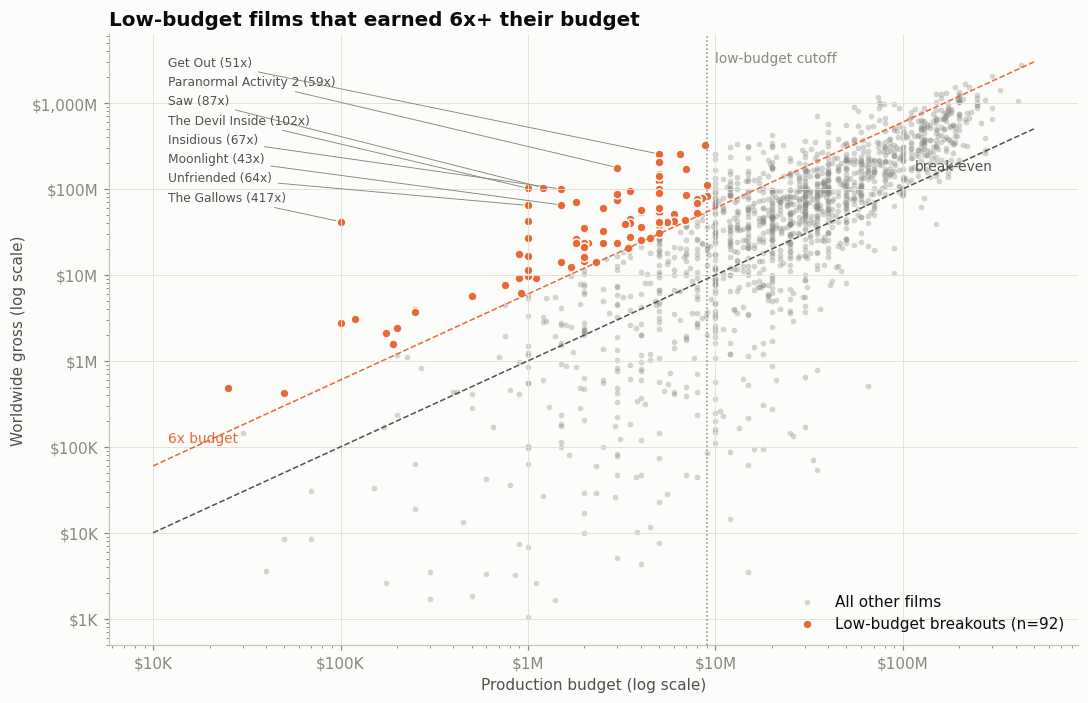

In [4]:
fig, ax = plt.subplots(figsize=(10, 6.5))
plot = df[df["worldwide_gross"] >= 1000]   # drop a few near-zero grosses so the log axis stays readable
other = plot[~(plot["low_budget"] & plot["breakout"])]
hits = plot[plot["low_budget"] & plot["breakout"]]

ax.scatter(other["production_budget"], other["worldwide_gross"], s=14, color=GRAY, alpha=0.35,
           linewidths=0, label="All other films")
ax.scatter(hits["production_budget"], hits["worldwide_gross"], s=34, color=ORANGE,
           edgecolor="#fcfcfb", linewidth=1, label=f"Low-budget breakouts (n={len(hits)})")

x = np.logspace(4, 8.7, 50)
ax.plot(x, x, ls="--", lw=1, color=INK2)
ax.plot(x, x * (1 + BREAKOUT_ROI), ls="--", lw=1, color=ORANGE)
ax.text(3e8, 3e8 * 0.55, "break-even", color=INK2, fontsize=9, ha="right")
ax.text(1.2e4, 1.2e4 * (1 + BREAKOUT_ROI) * 1.6, f"{1 + BREAKOUT_ROI}x budget", color=ORANGE, fontsize=9)
ax.axvline(LOW_BUDGET_CUTOFF, color=GRAY, lw=1, ls=":")
ax.text(LOW_BUDGET_CUTOFF * 1.1, 3e9, "low-budget cutoff", color=GRAY, fontsize=9)

# Label the top breakouts in a column in the empty upper-left, with leader lines
top = hits.nlargest(8, "roi").sort_values("worldwide_gross", ascending=False)
label_y = np.logspace(np.log10(3e9), np.log10(8e7), len(top))
for y_lab, (_, r) in zip(label_y, top.iterrows()):
    ax.annotate(f"{r['movie']} ({r['roi'] + 1:.0f}x)", (r["production_budget"], r["worldwide_gross"]),
                xytext=(1.2e4, y_lab), textcoords="data", fontsize=8, color=INK2, va="center",
                arrowprops=dict(arrowstyle="-", color=GRAY, lw=0.6, shrinkA=2, shrinkB=3))

ax.set(xscale="log", yscale="log", xlabel="Production budget (log scale)",
       ylabel="Worldwide gross (log scale)")
ax.xaxis.set_major_formatter(money); ax.yaxis.set_major_formatter(money)
ax.set_title("Low-budget films that earned 6x+ their budget")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 1b. Are breakouts concentrated in certain genres?
Breakout rate = share of low-budget films in the genre that hit ROI ≥ 5. A film counts toward every genre it's tagged with. Genres with fewer than 10 low-budget films are hidden because their rates are unreliable.

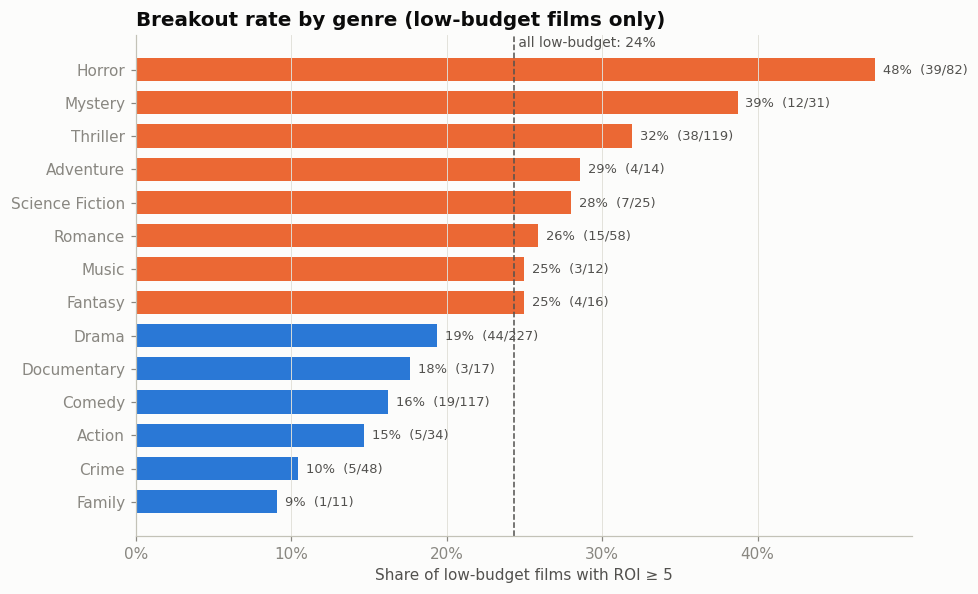

,genre,n,breakouts,rate,median_roi
8,Horror,82,39,0.48,4.30
10,Mystery,31,12,0.39,2.08
13,Thriller,119,38,0.32,0.87
1,Adventure,14,4,0.29,0.25
12,Science Fiction,25,7,0.28,0.97
11,Romance,58,15,0.26,1.28
7,Fantasy,16,4,0.25,0.34
9,Music,12,3,0.25,0.34
5,Drama,227,44,0.19,0.47
4,Documentary,17,3,0.18,0.33


In [5]:
rows = []
for g in GENRES:
    sub = low[low[g] == 1]
    if len(sub) >= 10:
        rows.append({"genre": g, "n": len(sub), "breakouts": sub["breakout"].sum(),
                     "rate": sub["breakout"].mean(), "median_roi": sub["roi"].median()})
genre_break = pd.DataFrame(rows).sort_values("rate")
overall_rate = low["breakout"].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [ORANGE if r > overall_rate else BLUE for r in genre_break["rate"]]
ax.barh(genre_break["genre"], genre_break["rate"], color=colors, height=0.7)
ax.axvline(overall_rate, color=INK2, ls="--", lw=1)
ax.text(overall_rate, len(genre_break) - 0.4, f" all low-budget: {overall_rate:.0%}",
        color=INK2, fontsize=9, va="bottom")
for i, r in enumerate(genre_break.itertuples()):
    ax.text(r.rate + 0.005, i, f"{r.rate:.0%}  ({r.breakouts}/{r.n})", va="center", fontsize=8.5, color=INK2)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlabel("Share of low-budget films with ROI ≥ 5")
ax.grid(axis="y", visible=False)
ax.set_title("Breakout rate by genre (low-budget films only)")
plt.tight_layout(); plt.show()

genre_break.sort_values("rate", ascending=False).round(2)

### 1c. Do breakouts cluster by release year or month?
The dataset covers mostly 2010–2018 (earlier and later years have only a handful of films), so the year chart is limited to that window.

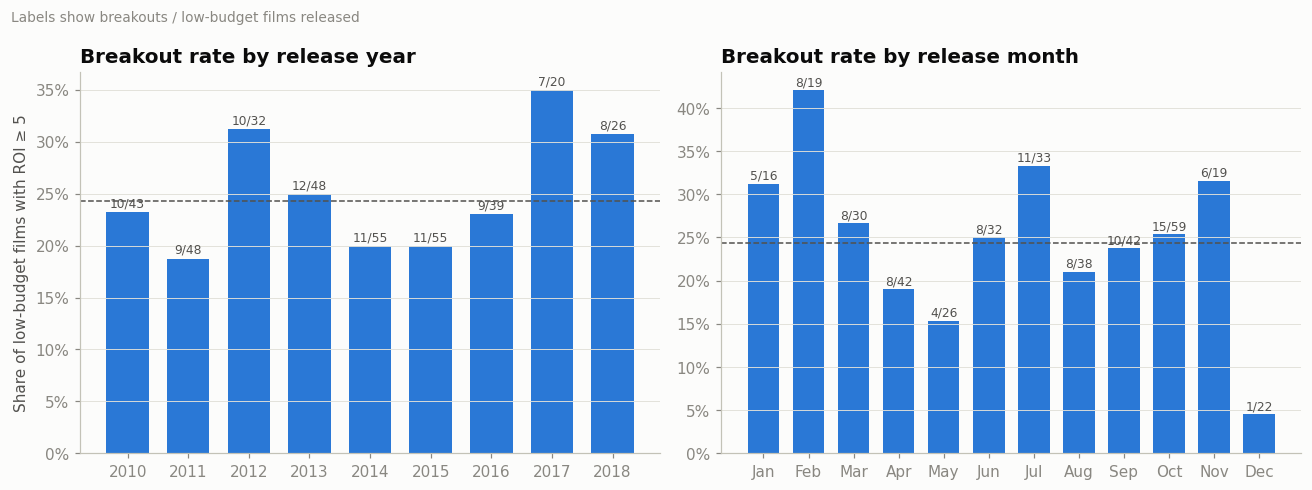

Breakout vs year: chi2 = 4.7, df = 8, p = 0.792
Breakout vs month: chi2 = 12.5, df = 11, p = 0.329


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

by_year = low[low["year"].between(2010, 2018)].groupby("year")["breakout"].agg(["mean", "sum", "count"])
axes[0].bar(by_year.index, by_year["mean"], color=BLUE, width=0.7)
for yr, r in by_year.iterrows():
    axes[0].text(yr, r["mean"] + 0.005, f"{int(r['sum'])}/{int(r['count'])}", ha="center", fontsize=8, color=INK2)
axes[0].set_title("Breakout rate by release year")
axes[0].set_xticks(by_year.index)

by_month = low.groupby("month")["breakout"].agg(["mean", "sum", "count"]).reindex(range(1, 13))
axes[1].bar(MONTHS, by_month["mean"], color=BLUE, width=0.7)
for i, r in enumerate(by_month.itertuples()):
    axes[1].text(i, r.mean + 0.005, f"{int(r.sum)}/{int(r.count)}", ha="center", fontsize=8, color=INK2)
axes[1].set_title("Breakout rate by release month")

for ax in axes:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
    ax.axhline(overall_rate, color=INK2, ls="--", lw=1)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Share of low-budget films with ROI ≥ 5")
fig.suptitle("Labels show breakouts / low-budget films released", x=0.01, ha="left", fontsize=9, color=GRAY)
plt.tight_layout(); plt.show()

# Chi-square tests: is breakout rate independent of year / month?
for col, sub in [("year", low[low["year"].between(2010, 2018)]), ("month", low)]:
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(sub[col], sub["breakout"]))
    print(f"Breakout vs {col}: chi2 = {chi2:.1f}, df = {dof}, p = {p:.3f}")

### 1d. What else correlates with ROI among low-budget films?
Spearman rank correlation with ROI (rank-based, so a few huge outliers can't dominate). Bars are orange when p < 0.05.

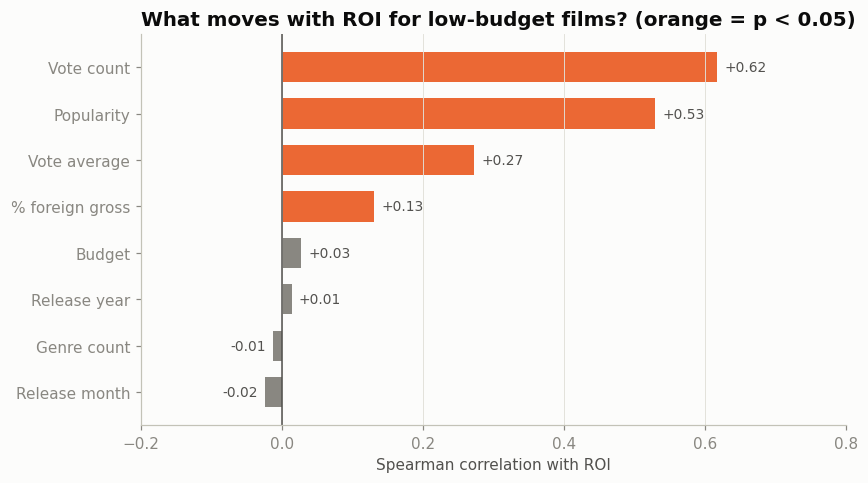

,feature,rho,p
7,Release month,-0.024,0.636
5,Genre count,-0.013,0.800
6,Release year,0.014,0.787
0,Budget,0.027,0.602
4,% foreign gross,0.131,0.011
2,Vote average,0.273,0.000
1,Popularity,0.530,0.000
3,Vote count,0.618,0.000


In [7]:
features = {"Budget": "production_budget", "Popularity": "popularity", "Vote average": "vote_average",
            "Vote count": "vote_count", "% foreign gross": "pct_foreign", "Genre count": "genre_count",
            "Release year": "year", "Release month": "month"}
corr = pd.DataFrame([
    {"feature": name, "rho": rho, "p": p}
    for name, col in features.items()
    for rho, p in [stats.spearmanr(low[col], low["roi"], nan_policy="omit")]
]).sort_values("rho")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(corr["feature"], corr["rho"], color=[ORANGE if p < 0.05 else GRAY for p in corr["p"]], height=0.65)
ax.axvline(0, color=INK2, lw=1)
for i, r in enumerate(corr.itertuples()):
    ax.text(r.rho + (0.01 if r.rho >= 0 else -0.01), i, f"{r.rho:+.2f}", va="center",
            ha="left" if r.rho >= 0 else "right", fontsize=9, color=INK2)
ax.set_xlabel("Spearman correlation with ROI")
ax.set_xlim(-0.2, max(0.8, corr["rho"].max() + 0.1))
ax.grid(axis="y", visible=False)
ax.set_title("What moves with ROI for low-budget films? (orange = p < 0.05)")
plt.tight_layout(); plt.show()
corr.round(3)

**Q1 takeaways** *(fill in after reviewing the charts)*
- Which genres are over-represented among low-budget breakouts?
- Is there a year or month effect, or is it noise (see the chi-square p-values)?
- Audience attention (vote count / popularity) vs. critical reception (vote average): which tracks ROI more closely?

---
## Q2. Seasonality: when do movies perform best, and does it differ by genre?

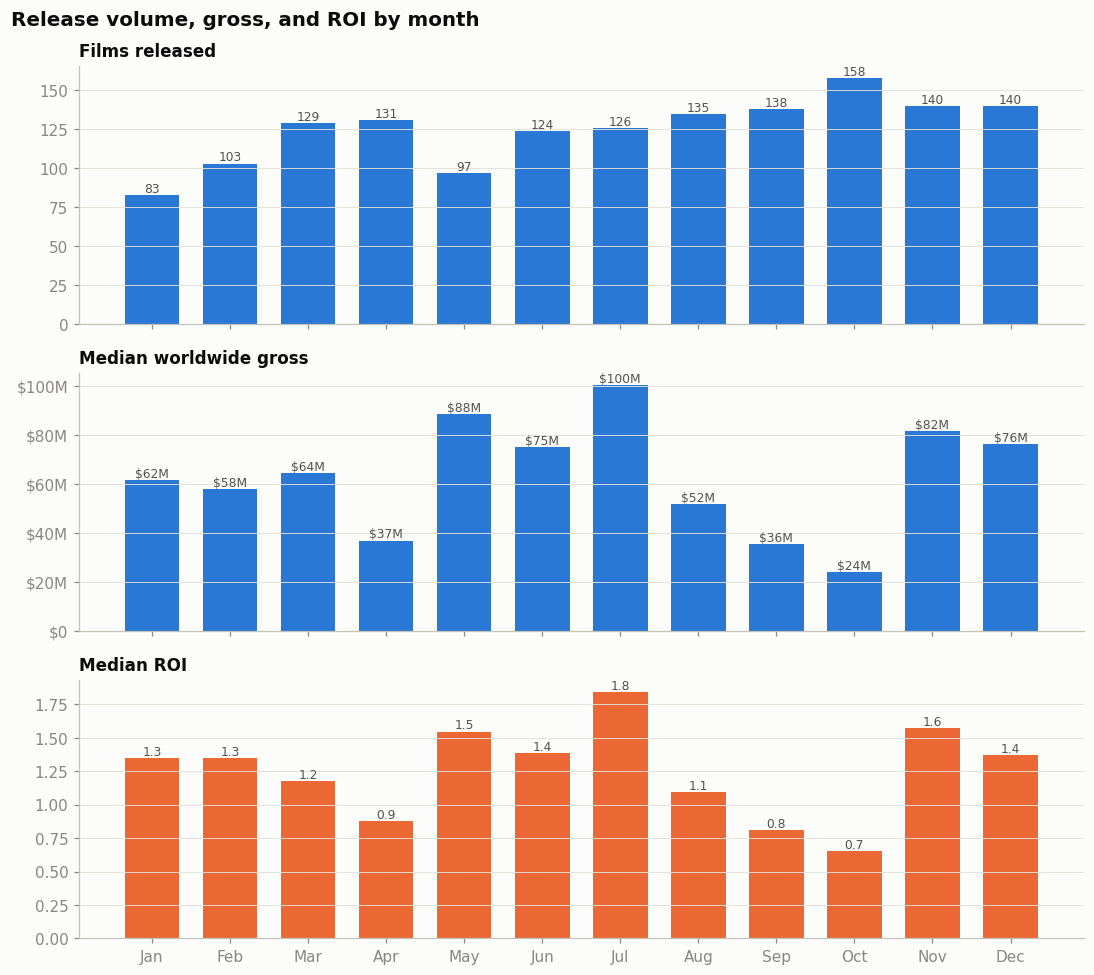

Kruskal-Wallis ROI across months: H = 26.3, p = 0.0058


In [8]:
monthly = df.groupby("month").agg(
    films=("movie", "count"),
    median_roi=("roi", "median"),
    median_gross=("worldwide_gross", "median"),
).reindex(range(1, 13))
monthly.index = MONTHS

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
panels = [("films", "Films released", "{:.0f}", BLUE),
          ("median_gross", "Median worldwide gross", None, BLUE),
          ("median_roi", "Median ROI", "{:.1f}", ORANGE)]
for ax, (col, title, fmt, color) in zip(axes, panels):
    ax.bar(MONTHS, monthly[col], color=color, width=0.7)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="x", visible=False)
    for i, v in enumerate(monthly[col]):
        label = f"${v/1e6:.0f}M" if fmt is None else fmt.format(v)
        ax.text(i, v, label, ha="center", va="bottom", fontsize=8, color=INK2)
axes[1].yaxis.set_major_formatter(money)
fig.suptitle("Release volume, gross, and ROI by month", x=0.01, ha="left", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

# Kruskal-Wallis: do ROI distributions differ across months? (non-parametric ANOVA)
groups = [g["roi"].dropna() for _, g in df.groupby("month")]
h, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis ROI across months: H = {h:.1f}, p = {p:.4f}")

### 2b. ROI distribution by month
Median bars can hide spread. This boxplot shows ROI on a log scale, `log10(1 + ROI)`, which equals `log10(gross / budget)`. 0 on the axis is break-even.

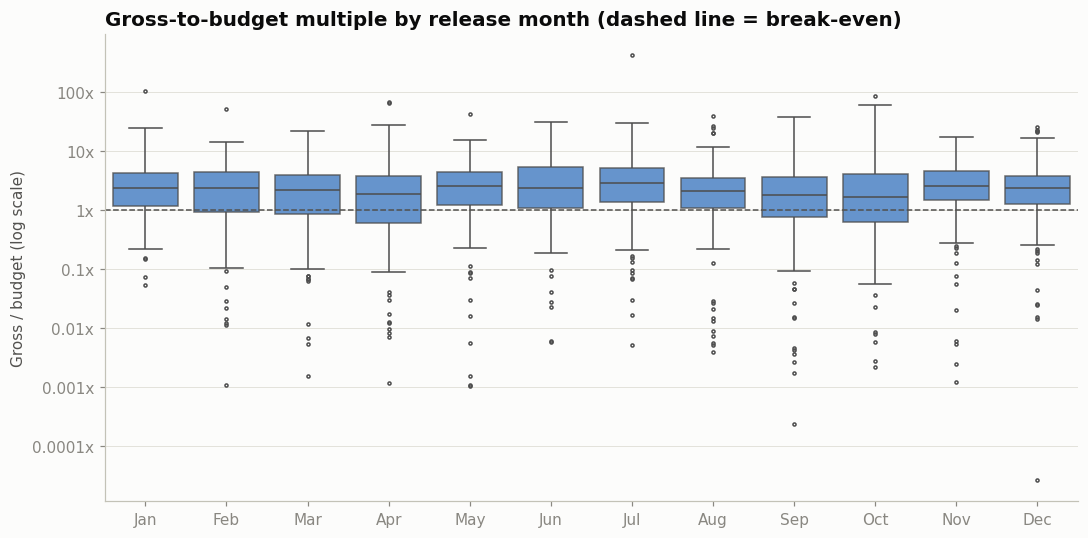

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="month_name", y=np.log10(1 + df["roi"]), color=BLUE, fliersize=2,
            linewidth=1, boxprops={"alpha": 0.8}, ax=ax)
ax.axhline(0, color=INK2, ls="--", lw=1)
ax.set(xlabel="", ylabel="Gross / budget (log scale)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{10**v:g}x"))
ax.set_title("Gross-to-budget multiple by release month (dashed line = break-even)")
plt.tight_layout(); plt.show()

### 2c. When does each genre get released?
Each row sums to 100%: the share of that genre's films released in each month. This tests the "horror in October, family in summer" idea on the **release** side.

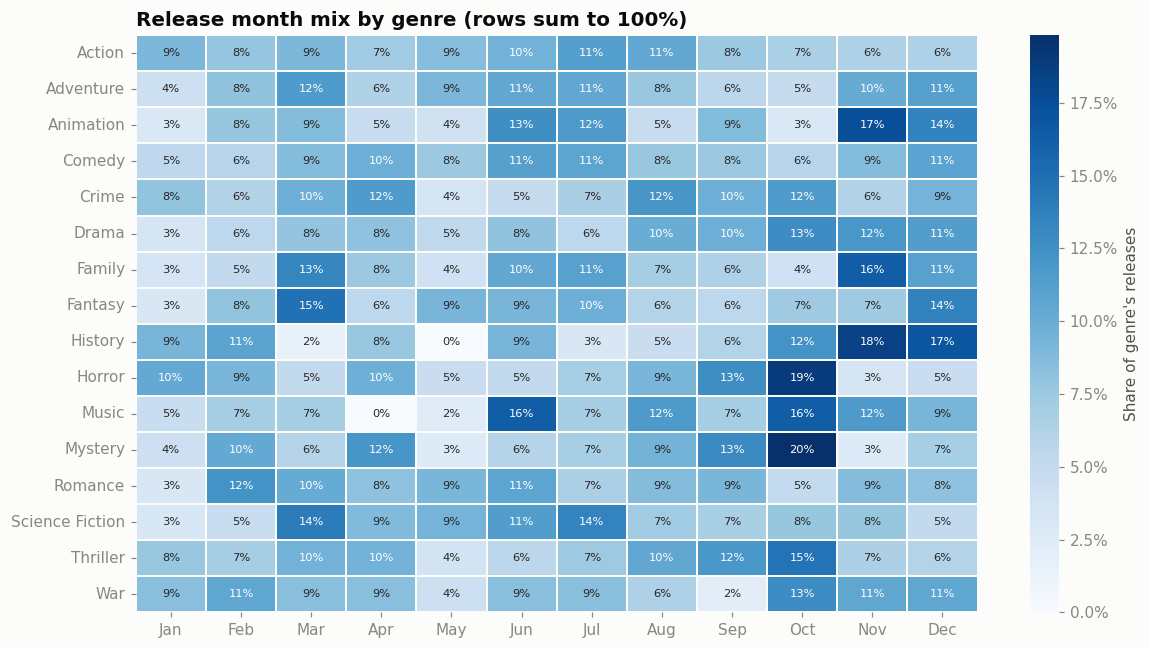

In [10]:
MIN_FILMS = 40   # only genres with enough films for a stable month-by-month picture
big_genres = [g for g in GENRES if df[g].sum() >= MIN_FILMS]

long = df.melt(id_vars=["month", "roi"], value_vars=big_genres, var_name="genre", value_name="has")
long = long[long["has"] == 1]

share = pd.crosstab(long["genre"], long["month"], normalize="index").reindex(columns=range(1, 13), fill_value=0)
share.columns = MONTHS

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(share, cmap="Blues", annot=True, fmt=".0%", annot_kws={"fontsize": 7.5},
            cbar_kws={"format": mtick.PercentFormatter(1), "label": "Share of genre's releases"},
            linewidths=1, linecolor="#fcfcfb", ax=ax)
ax.set(xlabel="", ylabel=""); ax.grid(False)
ax.set_title("Release month mix by genre (rows sum to 100%)")
plt.tight_layout(); plt.show()

### 2d. Genre × month: where is ROI highest?
Cell = median ROI for films of that genre released in that month. Each color is compared to the genre's **overall** median ROI, so the chart shows whether a genre does better or worse than usual in a given month. Orange = better than usual, blue = worse. Cells with fewer than 5 films are blank.

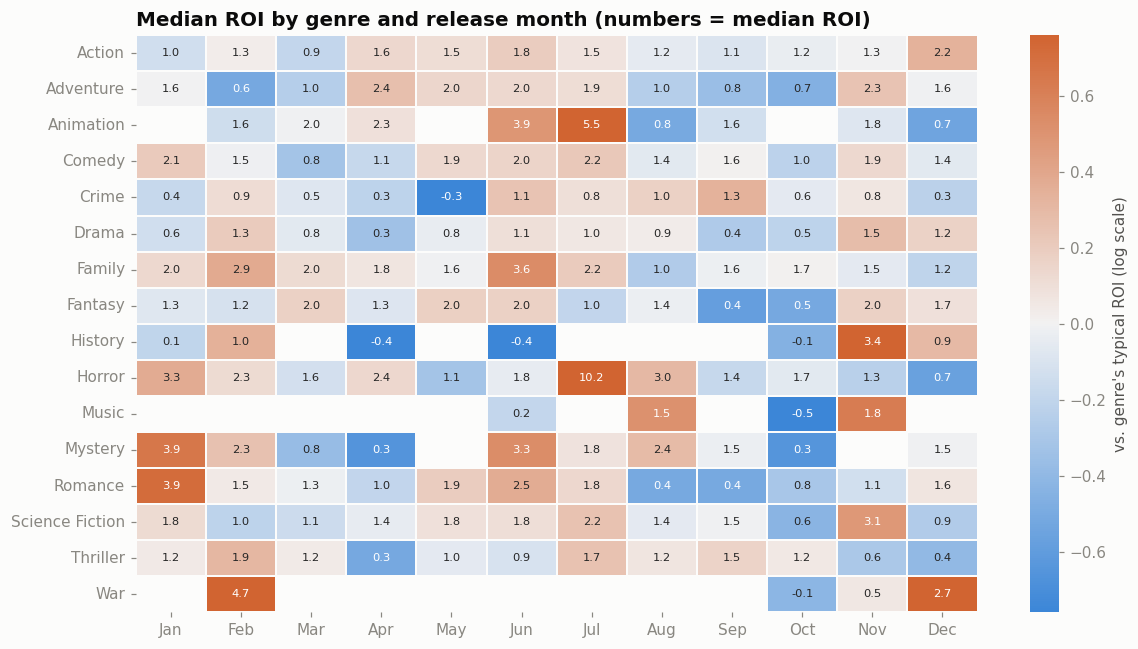

In [11]:
MIN_CELL = 5
med = long.groupby(["genre", "month"])["roi"].median().unstack().reindex(columns=range(1, 13))
cnt = long.groupby(["genre", "month"])["roi"].count().unstack().reindex(columns=range(1, 13)).fillna(0)
genre_med = long.groupby("genre")["roi"].median()

# difference (in log multiples) from the genre's own median
rel = np.log1p(med).sub(np.log1p(genre_med), axis=0).where(cnt >= MIN_CELL)
annot = med.where(cnt >= MIN_CELL).map(lambda v: "" if pd.isna(v) else f"{v:.1f}")
rel.columns = annot.columns = MONTHS

lim = np.nanpercentile(np.abs(rel.values), 95)
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(rel, cmap=sns.diverging_palette(250, 25, s=85, l=55, as_cmap=True), center=0, vmin=-lim, vmax=lim,
            annot=annot, fmt="", annot_kws={"fontsize": 7.5}, linewidths=1, linecolor="#fcfcfb",
            cbar_kws={"label": "vs. genre's typical ROI (log scale)"}, ax=ax)
ax.set(xlabel="", ylabel=""); ax.grid(False)
ax.set_title("Median ROI by genre and release month (numbers = median ROI)")
plt.tight_layout(); plt.show()

### 2e. Testing the specific hypotheses
Horror in October vs. the rest of the year, and Family/Animation in summer (May–Aug) vs. the rest of the year. Mann-Whitney U compares the two ROI distributions without assuming normality.

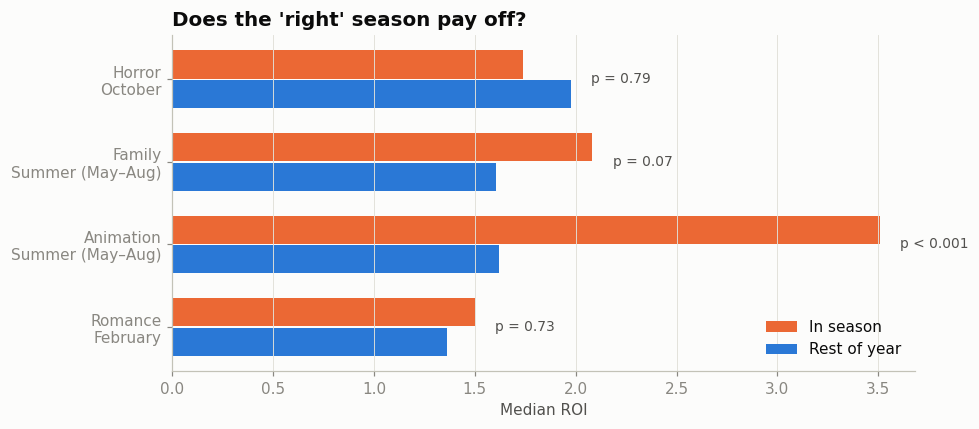

,genre,season,n_in,n_out,median_roi_in,median_roi_out,p_value
0,Horror,October,33,141,1.740,1.975,0.791
1,Family,Summer (May–Aug),56,116,2.083,1.604,0.071
2,Animation,Summer (May–Aug),34,69,3.508,1.619,0.000
3,Romance,February,24,172,1.500,1.364,0.728


In [12]:
SUMMER = [5, 6, 7, 8]
tests = [("Horror", "October", df["month"] == 10),
         ("Family", "Summer (May–Aug)", df["month"].isin(SUMMER)),
         ("Animation", "Summer (May–Aug)", df["month"].isin(SUMMER)),
         ("Romance", "February", df["month"] == 2)]

results = []
for genre, label, in_season in tests:
    g = df[df[genre] == 1]
    a, b = g.loc[in_season[g.index], "roi"].dropna(), g.loc[~in_season[g.index], "roi"].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    results.append({"genre": genre, "season": label, "n_in": len(a), "n_out": len(b),
                    "median_roi_in": a.median(), "median_roi_out": b.median(), "p_value": p})
results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(results))
ax.barh(y - 0.18, results["median_roi_in"], height=0.34, color=ORANGE, label="In season")
ax.barh(y + 0.18, results["median_roi_out"], height=0.34, color=BLUE, label="Rest of year")
ax.set_yticks(y, [f"{r.genre}\n{r.season}" for r in results.itertuples()])
for i, r in enumerate(results.itertuples()):
    ax.text(max(r.median_roi_in, r.median_roi_out) + 0.1, i, "p < 0.001" if r.p_value < 0.001 else f"p = {r.p_value:.2f}", va="center", fontsize=9, color=INK2)
ax.set_xlabel("Median ROI"); ax.grid(axis="y", visible=False)
ax.invert_yaxis(); ax.legend(loc="lower right")
ax.set_title("Does the 'right' season pay off?")
plt.tight_layout(); plt.show()
results.round(3)

**Q2 takeaways** *(fill in after reviewing the charts)*
- Which months release the most films vs. deliver the best median ROI? Are they the same months?
- Do genres release in their "expected" seasons (2c), and does that season actually give higher ROI (2d, 2e)?

---
## Q3. Does the number of genres matter, or only the primary genre?
`primary_genre` is the **first genre listed** in the `genres` column (TMDB lists the main genre first). `genre_count` is how many genres a film is tagged with. Films with 5+ genres are grouped together because there are only a few of them.

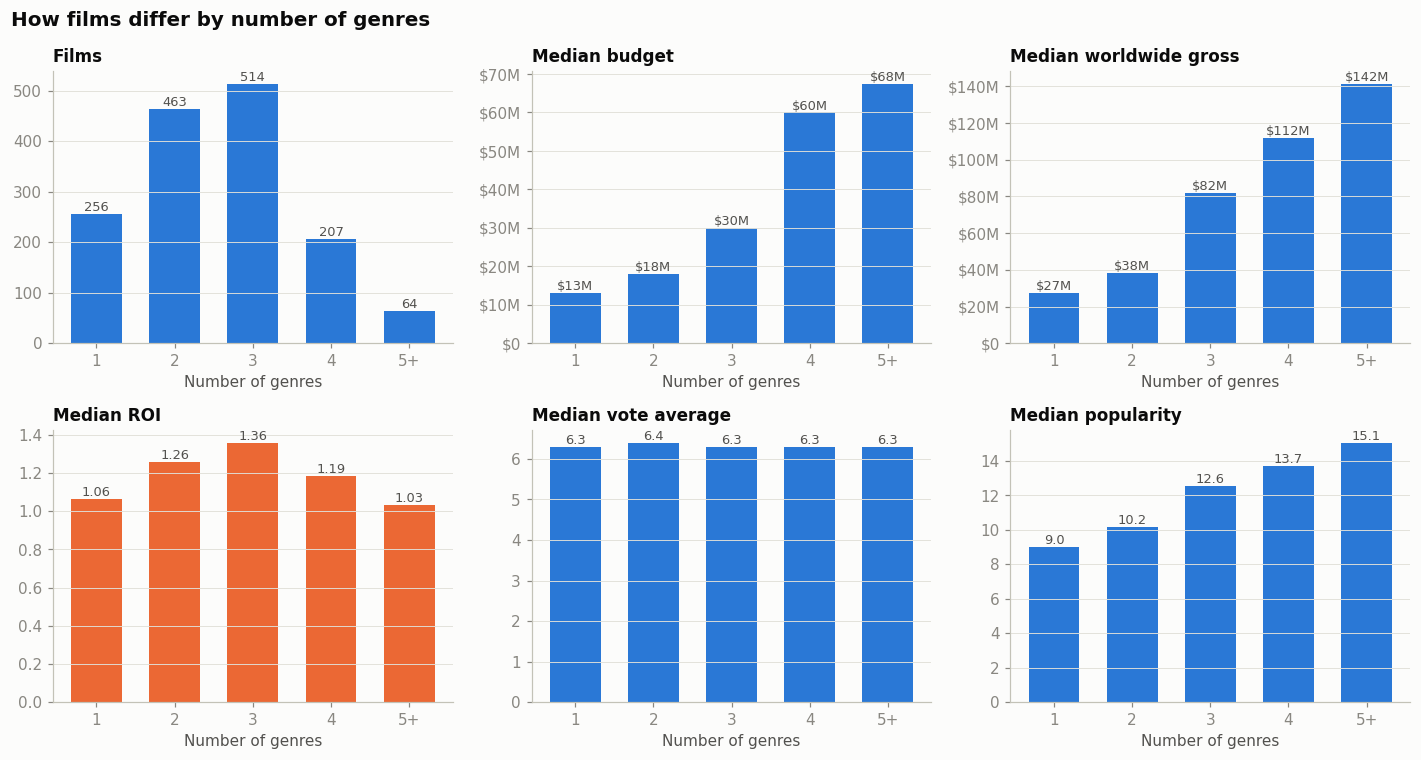

Spearman(genre_count, roi               ) = +0.027  p = 0.2871
Spearman(genre_count, production_budget ) = +0.374  p = 0.0000
Spearman(genre_count, worldwide_gross   ) = +0.288  p = 0.0000
Spearman(genre_count, vote_average      ) = +0.003  p = 0.9076
Spearman(genre_count, popularity        ) = +0.311  p = 0.0000


In [13]:
df["genre_count_grp"] = df["genre_count"].clip(upper=5).map(lambda n: "5+" if n == 5 else str(n))
ORDER = ["1", "2", "3", "4", "5+"]

summary = df.groupby("genre_count_grp").agg(
    films=("movie", "count"),
    median_budget=("production_budget", "median"),
    median_gross=("worldwide_gross", "median"),
    median_roi=("roi", "median"),
    median_vote=("vote_average", "median"),
    median_popularity=("popularity", "median"),
).reindex(ORDER)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
panels = [("films", "Films", "{:.0f}"), ("median_budget", "Median budget", "$"),
          ("median_gross", "Median worldwide gross", "$"), ("median_roi", "Median ROI", "{:.2f}"),
          ("median_vote", "Median vote average", "{:.1f}"), ("median_popularity", "Median popularity", "{:.1f}")]
for ax, (col, title, fmt) in zip(axes.flat, panels):
    ax.bar(ORDER, summary[col], color=ORANGE if col == "median_roi" else BLUE, width=0.65)
    for i, v in enumerate(summary[col]):
        ax.text(i, v, f"${v/1e6:.0f}M" if fmt == "$" else fmt.format(v), ha="center", va="bottom", fontsize=8.5, color=INK2)
    ax.set_title(title, fontsize=11); ax.grid(axis="x", visible=False)
    if fmt == "$": ax.yaxis.set_major_formatter(money)
    ax.set_xlabel("Number of genres")
fig.suptitle("How films differ by number of genres", x=0.01, ha="left", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

for col in ["roi", "production_budget", "worldwide_gross", "vote_average", "popularity"]:
    rho, p = stats.spearmanr(df["genre_count"], df[col], nan_policy="omit")
    print(f"Spearman(genre_count, {col:18s}) = {rho:+.3f}  p = {p:.4f}")

### 3b. ROI distribution by genre count

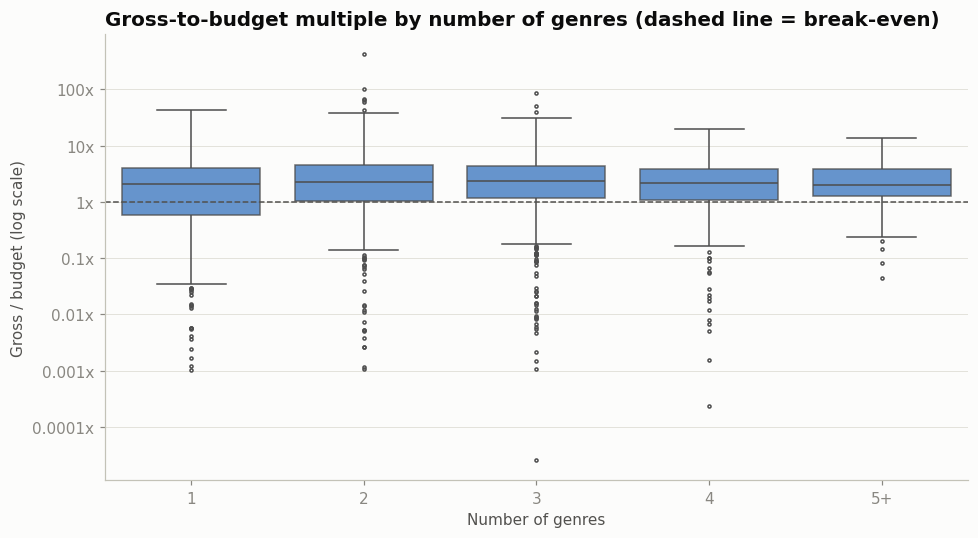

Kruskal-Wallis ROI across genre-count groups: H = 6.6, p = 0.1591


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="genre_count_grp", y=np.log10(1 + df["roi"]), order=ORDER, color=BLUE,
            fliersize=2, linewidth=1, boxprops={"alpha": 0.8}, ax=ax)
ax.axhline(0, color=INK2, ls="--", lw=1)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{10**v:g}x"))
ax.set(xlabel="Number of genres", ylabel="Gross / budget (log scale)")
ax.set_title("Gross-to-budget multiple by number of genres (dashed line = break-even)")
plt.tight_layout(); plt.show()

h, p = stats.kruskal(*[g["roi"].dropna() for _, g in df.groupby("genre_count_grp")])
print(f"Kruskal-Wallis ROI across genre-count groups: H = {h:.1f}, p = {p:.4f}")

### 3c. Primary genre × genre count
If only the primary genre mattered, each **row** would be roughly the same color across all genre counts. Numbers are median ROI (with number of films below). Cells with fewer than 5 films are blank.

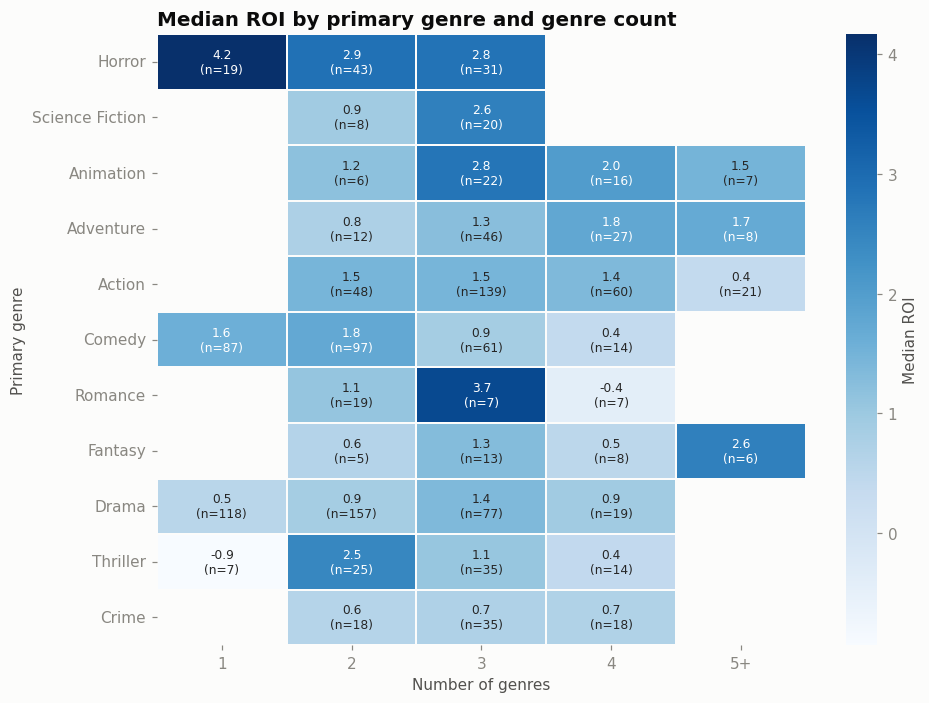

In [15]:
top_primary = df["primary_genre"].value_counts()
top_primary = top_primary[top_primary >= 30].index

sub = df[df["primary_genre"].isin(top_primary)]
med = sub.pivot_table(index="primary_genre", columns="genre_count_grp", values="roi", aggfunc="median").reindex(columns=ORDER)
cnt = sub.pivot_table(index="primary_genre", columns="genre_count_grp", values="roi", aggfunc="count").reindex(columns=ORDER).fillna(0)
med = med.where(cnt >= 5)
annot = pd.DataFrame(
    [[f"{m:.1f}\n(n={int(c)})" if pd.notna(m) else "" for m, c in zip(mrow, crow)]
     for mrow, crow in zip(med.values, cnt.values)],
    index=med.index, columns=med.columns)
order = med.median(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(med.loc[order], cmap="Blues", annot=annot.loc[order], fmt="", annot_kws={"fontsize": 8},
            linewidths=1, linecolor="#fcfcfb", cbar_kws={"label": "Median ROI"}, ax=ax)
ax.set(xlabel="Number of genres", ylabel="Primary genre"); ax.grid(False)
ax.set_title("Median ROI by primary genre and genre count")
plt.tight_layout(); plt.show()

### 3d. Does genre count add anything once we know the primary genre (and budget)?
Nested linear regressions on `log(1 + ROI)`:

| Model | Predictors |
|---|---|
| A | primary genre |
| B | primary genre + genre count |
| C | primary genre + log budget |
| D | primary genre + log budget + genre count |

If B beats A (and D beats C) by a significant F-test, genre count carries information beyond the primary genre. Model C/D controls for budget, since multi-genre films tend to be bigger productions.

In [16]:
reg = df.dropna(subset=["log_roi"]).copy()
reg["log_budget"] = np.log(reg["production_budget"])
X_primary = pd.get_dummies(reg["primary_genre"], drop_first=True, dtype=float)

def fit(X):
    X = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X, reg["log_roi"].values, rcond=None)
    resid = reg["log_roi"].values - X @ beta
    rss = resid @ resid
    tss = ((reg["log_roi"] - reg["log_roi"].mean()) ** 2).sum()
    return {"rss": rss, "k": X.shape[1], "r2": 1 - rss / tss, "beta": beta}

def f_test(small, big, n):
    df1, df2 = big["k"] - small["k"], n - big["k"]
    F = ((small["rss"] - big["rss"]) / df1) / (big["rss"] / df2)
    return F, stats.f.sf(F, df1, df2)

n = len(reg)
A = fit(X_primary)
B = fit(X_primary.assign(genre_count=reg["genre_count"]))
C = fit(X_primary.assign(log_budget=reg["log_budget"]))
D = fit(X_primary.assign(log_budget=reg["log_budget"], genre_count=reg["genre_count"]))

F_ab, p_ab = f_test(A, B, n)
F_cd, p_cd = f_test(C, D, n)
print(f"A  primary genre                         R² = {A['r2']:.3f}")
print(f"B  + genre count                         R² = {B['r2']:.3f}   F = {F_ab:.2f}, p = {p_ab:.4f}   "
      f"coef = {B['beta'][-1]:+.3f}")
print(f"C  primary genre + log budget            R² = {C['r2']:.3f}")
print(f"D  + genre count                         R² = {D['r2']:.3f}   F = {F_cd:.2f}, p = {p_cd:.4f}   "
      f"coef = {D['beta'][-1]:+.3f}")
print("\ncoef = change in log(1+ROI) per extra genre; exp(coef) - 1 ≈ % change in gross/budget multiple")

A  primary genre                         R² = 0.049
B  + genre count                         R² = 0.049   F = 0.12, p = 0.7304   coef = +0.016
C  primary genre + log budget            R² = 0.076
D  + genre count                         R² = 0.076   F = 0.34, p = 0.5603   coef = -0.027

coef = change in log(1+ROI) per extra genre; exp(coef) - 1 ≈ % change in gross/budget multiple


**Q3 takeaways** *(fill in after reviewing the charts)*
- Do films with more genres have higher budgets/grosses but not higher ROI?
- In 3c, is the color mostly consistent along each row (primary genre dominates) or does it shift with genre count?
- In 3d, does adding genre count improve the model significantly, before and after controlling for budget?